Enter probability of success (0 < p < 1):  0.6
Enter target number of successes:  3
Enter max failures to consider:  20


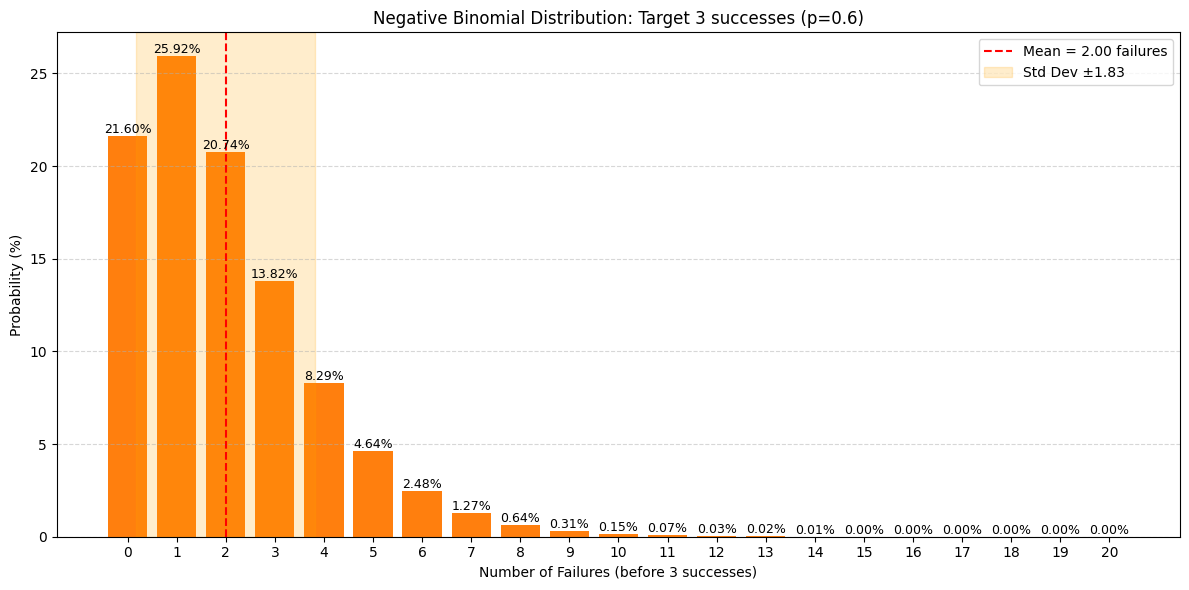

In [1]:
from math import comb, sqrt
import matplotlib.pyplot as plt
from collections import defaultdict

# Входни данни
p = float(input("Enter probability of success (0 < p < 1): "))
r = int(input("Enter target number of successes: "))
max_failures = int(input("Enter max failures to consider: "))

# Изчисляване на вероятностите
d = defaultdict(float)
for k in range(max_failures + 1):
    d[k] = comb(k + r - 1, k) * (p ** r) * ((1 - p) ** k)

# Сортиране на резултатите
sorted_d = dict(sorted(d.items(), key=lambda kvp: (-kvp[1], kvp[0])))

# Визуализация
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_d.keys(), [v*100 for v in sorted_d.values()], color='#ff7f0e')

# Добавяне на стойности над стълбовете
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=9)

# Настройки на графиката
plt.title(f'Negative Binomial Distribution: Target {r} successes (p={p})')
plt.xlabel(f'Number of Failures (before {r} successes)')
plt.ylabel('Probability (%)')
plt.xticks(list(sorted_d.keys()))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Статистически характеристики
mean = r * (1 - p) / p
variance = r * (1 - p) / (p ** 2)
std_dev = sqrt(variance)

plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f} failures')
plt.axvspan(mean - std_dev, mean + std_dev, color='orange', alpha=0.2,
            label=f'Std Dev ±{std_dev:.2f}')

plt.legend()
plt.tight_layout()
plt.show()